<a href="https://colab.research.google.com/github/aleksandrabegovic/apple_sentiment_analiza/blob/main/SentimentApple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip -q install yfinance

import pandas as pd
import numpy as np
import yfinance as yf
#Potrebne biblioteke za dalje analize.

In [ ]:
from google.colab import files
uploaded = files.upload()
#Podaci su učitani u okruženje, nakon čega su dalje obrađeni.

Saving apple_news_data.csv to apple_news_data.csv


In [ ]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.shape, df.columns
#Prikaz osnovnih informacija o datasetu, broj redova, broj kolona, kao i informacija o tome koje sve kolone postoje.

((29752, 10),
 Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
        'sentiment_polarity', 'sentiment_neg', 'sentiment_neu',
        'sentiment_pos'],
       dtype='object'))

In [ ]:
df.head(5)
#Prikaz prvih 5 redova, kako bismo videli sa kojim podacima radimo.

,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos
0,2024-11-27T16:39:00+00:00,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...",https://finance.yahoo.com/m/f5df3aa4-364b-31d6...,"0R2V.IL, AAPL.BA, AAPL.MX, AAPL.NEO, AAPL.SN, ...",NaN,0.0,0.0,1.0,0.0
1,2024-11-26T00:00:00+00:00,What Is a Stock Market Index?,What Is a Stock Market Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, MSFT.US",NaN,0.0,0.0,1.0,0.0
2,2024-11-26T00:00:00+00:00,"Could Investing $1,000 in Apple Make You a Mil...","Could Investing $1,000 in Apple Make You a Mil...",https://www.fool.com/investing/2024/11/26/coul...,AAPL.US,NaN,0.0,0.0,1.0,0.0
3,2024-11-26T00:00:00+00:00,Dow Jones Industrial Average,Dow Jones Industrial Average,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMGN.US, AMZN.US, CSCO.US, GOOG.US, G...",NaN,0.0,0.0,1.0,0.0
4,2024-11-26T00:00:00+00:00,What Is the S&P 500 Index?,What Is the S&P 500 Index?,https://www.fool.com/investing/stock-market/in...,"AAPL.US, AMZN.US, GOOG.US, GOOGL.US, META.US, ...",NaN,0.0,0.0,1.0,0.0


In [ ]:
df["date"] = pd.to_datetime(df["date"])
df[["date"]].head()
# Konverzija kolone 'date' u datetime format radi vremenskog
# usklađivanja finansijskih vesti sa podacima o cenama akcija.

,date
0,2024-11-27 16:39:00+00:00
1,2024-11-26 00:00:00+00:00
2,2024-11-26 00:00:00+00:00
3,2024-11-26 00:00:00+00:00
4,2024-11-26 00:00:00+00:00


In [ ]:
aapl_df = df[df["symbols"].str.contains("AAPL.US", na=False)].copy()

print("Broj AAPL.US vesti:", len(aapl_df))

Broj AAPL.US vesti: 29725


In [ ]:
aapl_df["year"] = pd.to_datetime(aapl_df["date"]).dt.year
aapl_df["year"].value_counts().sort_index()

,count
year,
2016,1
2017,3
2018,7
2019,41
2020,301
2021,7512
2022,8967
2023,7709
2024,5184


In [ ]:
random_news = aapl_df.sample(1)

print("DATUM:", random_news["date"].values[0])
print("NASLOV:", random_news["title"].values[0])
print("TEKST:", random_news["content"].values[0])

DATUM: 2024-04-16T07:10:07.000000000
NASLOV: Apple wants to spend more on suppliers in Vietnam, state media says
TEKST: HANOI (Reuters) - Apple Inc. CEO Tim Cook said on Tuesday in Hanoi the U.S. tech giant wanted to boost its investment in Vietnam, state media reported.

Cook made the statement at a meeting with Vietnamese Prime Minister Pham Minh Chinh during his visit to Vietnam, a key manufacturing hub for Apple.

Separately, in a statement released on Monday on its website, Apple said it would increase its spending on suppliers in Vietnam, where it has created some 200,000 jobs.

Vietnam will set up a working group to support Apple's investment in the country, Prime Minister Pham Minh Chinh told Cook during the meeting.

Apple did not respond to a request for additional comments about its planned spending.

Cook arrived in Hanoi on Monday for the two-day visit during which he met suppliers, students, content creators and users of Apple products.

(Reporting by Khanh Vu and Frances

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd

In [ ]:
import yfinance as yf

aapl_prices = yf.download("AAPL", start="2016-01-01", end="2024-12-31")

aapl_prices = aapl_prices.reset_index()

aapl_prices = aapl_prices.rename(columns={
    "Date": "date",
    "Close": "close"
})

/tmp/ipykernel_21614/3562014403.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl_prices = yf.download("AAPL", start="2016-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [ ]:
aapl_df["date"] = pd.to_datetime(aapl_df["date"]).dt.date
aapl_prices["date"] = pd.to_datetime(aapl_prices["date"]).dt.date

aapl_df["date"] = pd.to_datetime(aapl_df["date"])
aapl_prices["date"] = pd.to_datetime(aapl_prices["date"])

aapl_df = aapl_df.sort_values("date")
aapl_prices = aapl_prices.sort_values("date")

aapl_prices.columns = aapl_prices.columns.droplevel(1)
aapl_prices = aapl_prices.rename(columns={"Close": "close"})

In [ ]:
import pandas as pd

# 1) priprema price tabele
aapl_prices = aapl_prices.sort_values("date").copy()

aapl_prices["close_t"] = aapl_prices["close"]
aapl_prices["close_t1"] = aapl_prices["close"].shift(-1)
aapl_prices["close_t2"] = aapl_prices["close"].shift(-2)
aapl_prices["close_t3"] = aapl_prices["close"].shift(-3)
aapl_prices["close_t5"] = aapl_prices["close"].shift(-5)
aapl_prices["close_t7"] = aapl_prices["close"].shift(-7)

aapl_prices["open_t1"] = aapl_prices["Open"].shift(-1)
aapl_prices["open_t2"] = aapl_prices["Open"].shift(-2)

aapl_prices["high_t1"] = aapl_prices["High"].shift(-1)
aapl_prices["high_t2"] = aapl_prices["High"].shift(-2)
aapl_prices["high_t3"] = aapl_prices["High"].shift(-3)

aapl_prices["low_t1"] = aapl_prices["Low"].shift(-1)
aapl_prices["low_t2"] = aapl_prices["Low"].shift(-2)
aapl_prices["low_t3"] = aapl_prices["Low"].shift(-3)

aapl_prices["avg_t"] = (
    aapl_prices["Open"] +
    aapl_prices["High"] +
    aapl_prices["Low"] +
    aapl_prices["close"]
) / 4

aapl_prices["avg_t1"] = aapl_prices["avg_t"].shift(-1)

# 2) merge vesti, sledeći trading dan
aapl_merged = pd.merge_asof(
    aapl_df.sort_values("date"),
    aapl_prices[[
        "date",
        "close_t", "close_t1", "close_t2", "close_t3",
        "close_t5", "close_t7",
        "open_t1", "open_t2",
        "high_t1", "high_t2", "high_t3",
        "low_t1", "low_t2", "low_t3",
        "avg_t", "avg_t1"
    ]],
    on="date",
    direction="forward"
)

# 3) osnovni prinosi
aapl_merged["return_close_close"] = (
    aapl_merged["close_t1"] - aapl_merged["close_t"]
) / aapl_merged["close_t"]

aapl_merged["return_open_close"] = (
    aapl_merged["close_t1"] - aapl_merged["open_t1"]
) / aapl_merged["open_t1"]

aapl_merged["return_open_open"] = (
    aapl_merged["open_t2"] - aapl_merged["open_t1"]
) / aapl_merged["open_t1"]

aapl_merged["return_avg_avg"] = (
    aapl_merged["avg_t1"] - aapl_merged["avg_t"]
) / aapl_merged["avg_t"]

# 4) dodatni prinosi za 2, 3, 5 i 7 dana
aapl_merged["return_2d"] = (
    aapl_merged["close_t2"] - aapl_merged["close_t"]
) / aapl_merged["close_t"]

aapl_merged["return_3d"] = (
    aapl_merged["close_t3"] - aapl_merged["close_t"]
) / aapl_merged["close_t"]

aapl_merged["return_5d"] = (
    aapl_merged["close_t5"] - aapl_merged["close_t"]
) / aapl_merged["close_t"]

aapl_merged["return_7d"] = (
    aapl_merged["close_t7"] - aapl_merged["close_t"]
) / aapl_merged["close_t"]

# 5) targeti za neuronsku mrežu
aapl_merged["y_1d"] = (aapl_merged["return_close_close"] > 0).astype(int)
aapl_merged["y_2d"] = (aapl_merged["return_2d"] > 0).astype(int)
aapl_merged["y_3d"] = (aapl_merged["return_3d"] > 0).astype(int)
aapl_merged["y_5d"] = (aapl_merged["return_5d"] > 0).astype(int)
aapl_merged["y_7d"] = (aapl_merged["return_7d"] > 0).astype(int)

# 6) profesorov target
aapl_merged["max_high_3d"] = aapl_merged[["high_t1", "high_t2", "high_t3"]].max(axis=1)
aapl_merged["min_low_3d"] = aapl_merged[["low_t1", "low_t2", "low_t3"]].min(axis=1)

aapl_merged["up_move_3d"] = aapl_merged["max_high_3d"] - aapl_merged["close_t"]
aapl_merged["down_move_3d"] = aapl_merged["min_low_3d"] - aapl_merged["close_t"]

aapl_merged["y_prof_3d"] = (
    abs(aapl_merged["up_move_3d"]) > abs(aapl_merged["down_move_3d"])
).astype(int)

# 7) kompanija
aapl_merged["company"] = "AAPL"

# 8) uklanjanje redova sa nedostajućim vrednostima
aapl_merged = aapl_merged.dropna(subset=[
    "return_close_close",
    "return_2d",
    "return_3d",
    "return_5d",
    "return_7d",
    "max_high_3d",
    "min_low_3d"
])

print(aapl_merged.shape)
aapl_merged.head()

(29725, 46)


,date,title,content,link,symbols,tags,sentiment_polarity,sentiment_neg,sentiment_neu,sentiment_pos,...,y_2d,y_3d,y_5d,y_7d,max_high_3d,min_low_3d,up_move_3d,down_move_3d,y_prof_3d,company
0,2016-02-19,Payment Data Systems Announces Apple Pay Suppo...,"SAN ANTONIO, Feb. 19, 2016 (GLOBE NEWSWIRE) ...",https://www.globenewswire.com/news-release/201...,"AAPL.US, PYDS.US, USIO.US","AKIMBO, AKIMBO CARD, APPLE, APPLE PAY, FICENTI...",0.994,0.023,0.869,0.108,...,0,1,1,1,21.925755,21.115704,0.194586,-0.615465,0,AAPL
1,2017-10-05,New Research: Key Drivers of Growth for Micros...,"NEW YORK, Oct. 05, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"AAPL.US, AMZN.US, INTC.US, MSFT.US, QCOM.US, T...",FUNDAMENTAL MARKETS,0.997,0.008,0.925,0.067,...,1,1,1,1,36.801409,36.000150,0.607920,-0.193339,1,AAPL
2,2017-11-27,"Factors of Influence in 2018, Key Indicators a...","NEW YORK, Nov. 27, 2017 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"AAPL.US, CSCO.US, GD.US, HPE.US, NVDA.US, S.US",FUNDAMENTAL MARKETS,0.997,0.008,0.926,0.065,...,0,0,0,0,40.877182,39.074906,0.182323,-1.619952,0,AAPL
3,2017-11-30,"BioTelemetry, Inc. Enters Agreement to Provide...","MALVERN, Pa., Nov. 30, 2017 (GLOBE NEWSWIRE)...",https://www.globenewswire.com/news-release/201...,"AAPL.US, BEAT.US","BIOTELEMETRY, INC, NASDAQ:BEAT",0.989,0.021,0.804,0.174,...,0,0,0,1,40.351226,39.364753,0.180004,-0.806470,0,AAPL
4,2018-01-31,Investor Expectations to Drive Momentum within...,"NEW YORK, Jan. 31, 2018 (GLOBE NEWSWIRE) -- ...",https://www.globenewswire.com/news-release/201...,"AAPL.US, AVHI.US, FARM.US, GM.US, SGRY.US",FUNDAMENTAL MARKETS,0.995,0.009,0.937,0.054,...,0,0,0,0,39.416193,36.466173,0.278169,-2.671851,0,AAPL


In [ ]:
aapl_merged[["date", "title", "close_t", "close_t1", "return_close_close","return_open_open","return_open_close","return_avg_avg"]].head()

,date,title,close_t,close_t1,return_close_close,return_open_open,return_open_close,return_avg_avg
0,2016-02-19,Payment Data Systems Announces Apple Pay Suppo...,21.731169,21.921228,0.008746,0.000935,0.005918,0.003666
1,2017-10-05,New Research: Key Drivers of Growth for Micros...,36.193489,36.172512,-0.000580,0.005420,0.002129,0.002035
2,2017-11-27,"Factors of Influence in 2018, Key Indicators a...",40.694859,40.456421,-0.005859,-0.009581,-0.007057,-0.004960
3,2017-11-30,"BioTelemetry, Inc. Enters Agreement to Provide...",40.171223,39.984234,-0.004655,0.014887,0.006473,-0.002474
4,2018-01-31,Investor Expectations to Drive Momentum within...,39.138023,39.219837,0.002090,-0.006999,0.003649,0.001629


In [ ]:
d = pd.to_datetime("2021-07-28")

aapl_merged[aapl_merged["date"].dt.date == d.date()][["close_t","close_t1"]].drop_duplicates()

,close_t,close_t1
4175,141.319534,141.962875


In [ ]:
aapl_merged["direction_close_close"] = aapl_merged["return_close_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

aapl_merged["direction_open_close"] = aapl_merged["return_open_close"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

aapl_merged["direction_open_open"] = aapl_merged["return_open_open"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

aapl_merged["direction_avg_avg"] = aapl_merged["return_avg_avg"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

In [ ]:
aapl_merged["direction_close_close"].value_counts()

,count
direction_close_close,
UP,15361
DOWN,14364


In [ ]:
aapl_merged["direction_open_close"].value_counts()

,count
direction_open_close,
UP,15634
DOWN,14091


In [ ]:
aapl_merged["direction_open_open"].value_counts()

,count
direction_open_open,
UP,15416
DOWN,14309


In [ ]:
aapl_merged["direction_avg_avg"].value_counts()

,count
direction_avg_avg,
UP,15986
DOWN,13739


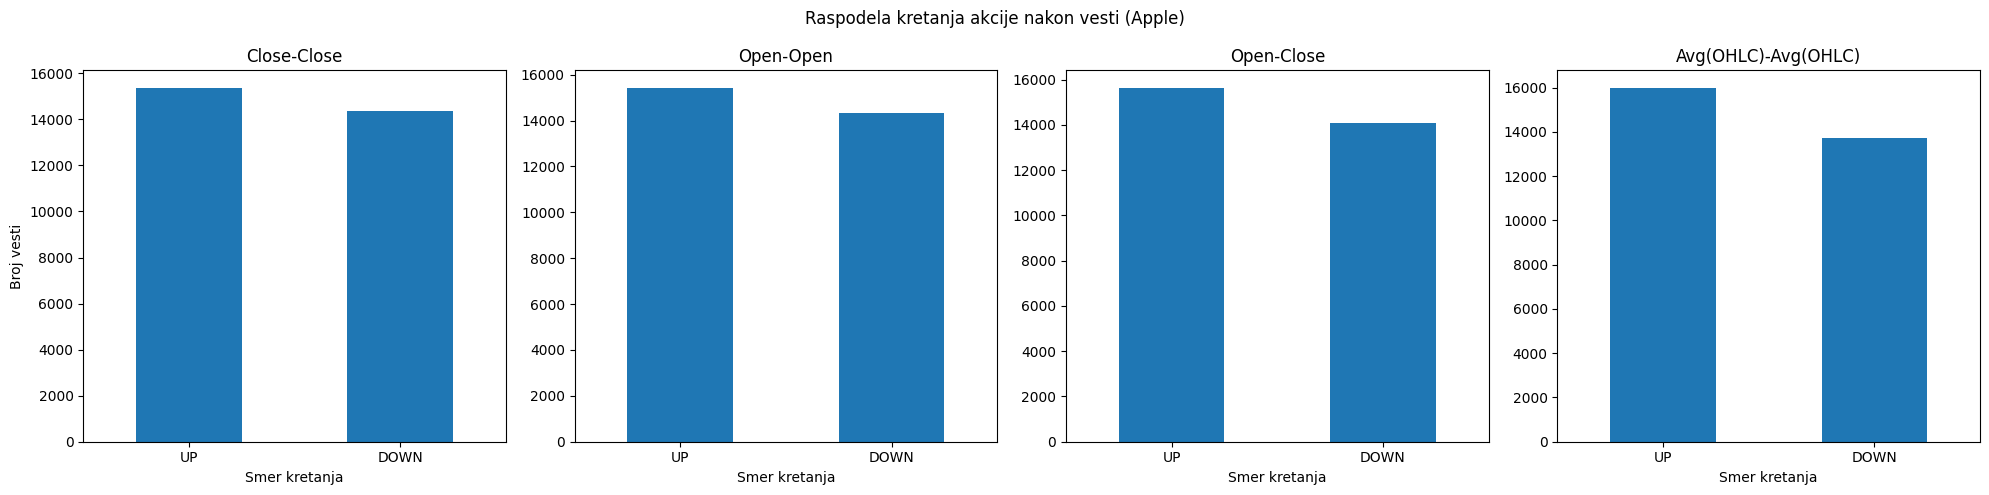

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# close-close
aapl_merged["direction_close_close"].value_counts().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Close-Close")
axes[0].set_xlabel("Smer kretanja")
axes[0].set_ylabel("Broj vesti")
axes[0].tick_params(axis='x', rotation=0)

# open-open
aapl_merged["direction_open_open"].value_counts().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Open-Open")
axes[1].set_xlabel("Smer kretanja")
axes[1].tick_params(axis='x', rotation=0)

# open-close
aapl_merged["direction_open_close"].value_counts().plot(
    kind="bar", ax=axes[2]
)
axes[2].set_title("Open-Close")
axes[2].set_xlabel("Smer kretanja")
axes[2].tick_params(axis='x', rotation=0)

# avg-avg
aapl_merged["direction_avg_avg"].value_counts().plot(
    kind="bar", ax=axes[3]
)
axes[3].set_title("Avg(OHLC)-Avg(OHLC)")
axes[3].set_xlabel("Smer kretanja")
axes[3].tick_params(axis='x', rotation=0)

plt.suptitle("Raspodela kretanja akcije nakon vesti (Apple)")

plt.tight_layout()
plt.show()

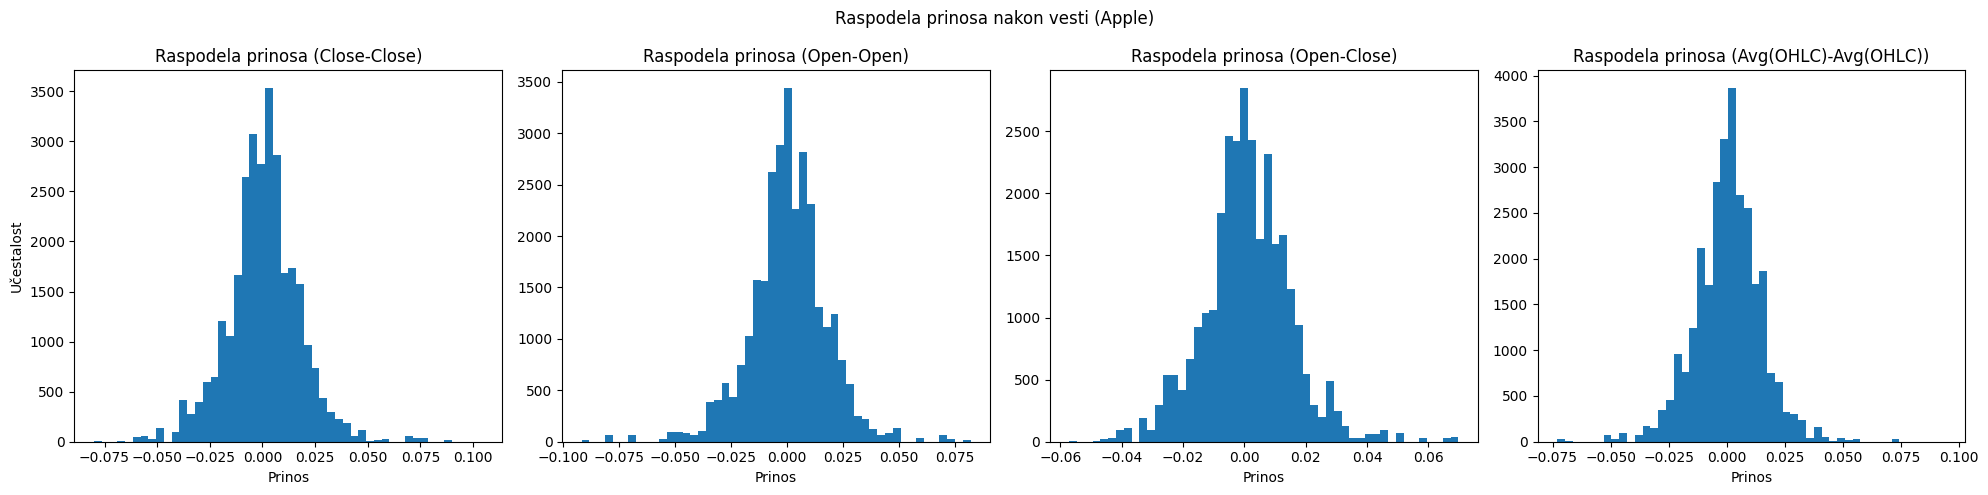

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20,5))

# Close-Close
axes[0].hist(aapl_merged["return_close_close"].dropna(), bins=50)
axes[0].set_title("Raspodela prinosa (Close-Close)")
axes[0].set_xlabel("Prinos")
axes[0].set_ylabel("Učestalost")

# Open-Open
axes[1].hist(aapl_merged["return_open_open"].dropna(), bins=50)
axes[1].set_title("Raspodela prinosa (Open-Open)")
axes[1].set_xlabel("Prinos")

# Open-Close
axes[2].hist(aapl_merged["return_open_close"].dropna(), bins=50)
axes[2].set_title("Raspodela prinosa (Open-Close)")
axes[2].set_xlabel("Prinos")

# Avg-Avg
axes[3].hist(aapl_merged["return_avg_avg"].dropna(), bins=50)
axes[3].set_title("Raspodela prinosa (Avg(OHLC)-Avg(OHLC))")
axes[3].set_xlabel("Prinos")

plt.suptitle("Raspodela prinosa nakon vesti (Apple)")

plt.tight_layout()
plt.show()

In [ ]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [ ]:
from typing import Optional
from enum import Enum
from pydantic import BaseModel, Field


class Sentiment(str, Enum):
    NEGATIVE = "negative"
    NEUTRAL = "neutral"
    POSITIVE = "positive"


class Topic(str, Enum):
    IPHONE = "iphone_sales_demand"
    MAC = "mac_computers"
    SERVICES = "services_icloud_apple_music"
    WEARABLES = "wearables_apple_watch_airpods"
    APP_STORE = "app_store_developer_ecosystem"
    AI = "ai_ml"
    SUPPLY_CHAIN = "supply_chain_production"
    REGULATION = "regulation_antitrust"
    LEGAL = "legal_lawsuit"
    MACRO = "macro_economy_rates_inflation"
    MERGERS = "mna_partnerships"
    OTHER = "other"


class NewsAnnotation(BaseModel):
    """Structured annotation for Apple-related financial news."""

    sentiment: Optional[Sentiment] = Field(
        default=None,
        description="Overall sentiment expressed toward Apple in the news.",
        examples=[Sentiment.NEGATIVE]
    )

    sentiment_score: Optional[float] = Field(
        default=None,
        description="Sentiment score between -1 and 1 where -1 is very negative, 0 neutral, and 1 very positive.",
        examples=[-0.8, 0.0, 0.7]
    )

    topic: Optional[Topic] = Field(
        default=None,
        description="Main topic of the news related to Apple. Choose the closest single category.",
        examples=[Topic.IPHONE]
    )

In [ ]:
import pandas as pd

# funkcija za spajanje title i content
def combine_title_content(row, max_chars=2000):
    title = str(row.get("title", "") or "").strip()
    content = str(row.get("content", "") or "").strip()

    if len(content) > max_chars:
        content = content[:max_chars]

    if content:
        return f"TITLE: {title}\nCONTENT: {content}"

    return f"TITLE: {title}"


aapl_merged["text_for_ie"] = aapl_merged.apply(combine_title_content, axis=1)

aapl_merged[["text_for_ie"]].head(2)

,text_for_ie
0,TITLE: Payment Data Systems Announces Apple Pa...
1,TITLE: New Research: Key Drivers of Growth for...


In [ ]:
!pip -q install openai langchain langchain-openai pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 17.2 MB/s eta 0:00:00


In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

system_msg = """
You are an expert financial information extraction agent.
Determine Apple-targeted sentiment based on the impact on Apple Inc. (Apple, AAPL).

Return:
- sentiment: EXACTLY one of (positive, neutral, negative)
- sentiment_score: a number between -1 and 1

Rules for sentiment_score:
- -1 = extremely negative news for Apple
- 0 = neutral impact
- 1 = extremely positive news
- intermediate values allowed (e.g., -0.3, 0.6)

The sentiment_score must be consistent with the sentiment label.

If Apple is mentioned but the impact is unclear, return neutral and sentiment_score = 0.
Return null ONLY if Apple is not mentioned at all.
Use lowercase only.
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_msg),
    ("human", "Analyze the following Apple-related news:\n{text}")
])

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

ie_chain = prompt | llm.with_structured_output(NewsAnnotation)

In [ ]:
from time import sleep
import pandas as pd

def tag_df_openai(
    df: pd.DataFrame,
    text_col="text_for_ie",
    sleep_sec=0.4,
    save_every=100,
    save_path=None
):
    """
    Automatska anotacija finansijskih vesti pomoću LLM modela
    za Apple kompaniju.
    """

    out = df.copy()
    sentiments, scores, topics = [], [], []

    for i, txt in enumerate(out[text_col], start=1):
        try:
            res = ie_chain.invoke({"text": txt})

            sentiments.append(res.sentiment.value if res.sentiment else None)
            scores.append(res.sentiment_score if res.sentiment_score is not None else None)
            topics.append(res.topic.value if res.topic else None)

        except Exception:
            sentiments.append(None)
            scores.append(None)
            topics.append(None)

        if i % 50 == 0:
            print(f"Processed {i} rows")

        if save_path and i % save_every == 0:
            out.loc[:i-1, "sentiment"] = sentiments
            out.loc[:i-1, "sentiment_score"] = scores
            out.loc[:i-1, "topic"] = topics
            out.to_csv(save_path, index=False)

        sleep(sleep_sec)

    out["sentiment"] = sentiments
    out["sentiment_score"] = scores
    out["topic"] = topics

    # FINALNO ČUVANJE
    if save_path:
        out.to_csv(save_path, index=False)
        print(f"Final save completed: {save_path}")

    return out

In [ ]:
aapl_tagged = tag_df_openai(
    aapl_merged,
    text_col="text_for_ie",
    save_path="/content/drive/MyDrive/aapl_news_tagged2.csv"
)

Processed 50 rows
Processed 100 rows
Processed 150 rows
Processed 200 rows
Processed 250 rows
Processed 300 rows
Processed 350 rows
Processed 400 rows
Processed 450 rows
Processed 500 rows
Processed 550 rows
Processed 600 rows
Processed 650 rows
Processed 700 rows
Processed 750 rows
Processed 800 rows
Processed 850 rows
Processed 900 rows
Processed 950 rows
Processed 1000 rows
Processed 1050 rows
Processed 1100 rows
Processed 1150 rows
Processed 1200 rows
Processed 1250 rows
Processed 1300 rows
Processed 1350 rows
Processed 1400 rows
Processed 1450 rows
Processed 1500 rows
Processed 1550 rows
Processed 1600 rows
Processed 1650 rows
Processed 1700 rows
Processed 1750 rows
Processed 1800 rows
Processed 1850 rows
Processed 1900 rows
Processed 1950 rows
Processed 2000 rows
Processed 2050 rows
Processed 2100 rows
Processed 2150 rows
Processed 2200 rows
Processed 2250 rows
Processed 2300 rows
Processed 2350 rows
Processed 2400 rows
Processed 2450 rows
Processed 2500 rows
Processed 2550 rows


KeyboardInterrupt: 

In [ ]:
import pandas as pd

# učitaj postojeći fajl
existing = pd.read_csv("/content/drive/MyDrive/aapl_news_tagged2.csv")


start_idx = existing["sentiment"].notna().sum()

print("Nastavljam od reda:", start_idx)

Nastavljam od reda: 22770


In [ ]:
remaining = aapl_merged.iloc[start_idx:].copy()



In [ ]:
def tag_df_openai_resume(
    existing,
    remaining,
    text_col="text_for_ie",
    sleep_sec=0.4,
    save_every=100,
    save_path=None
):
    out = remaining.copy().reset_index(drop=True)

    for col in ["sentiment", "sentiment_score", "topic"]:
        if col not in out.columns:
            out[col] = None

    sentiments, scores, topics = [], [], []

    for i, txt in enumerate(out[text_col], start=1):
        try:
            res = ie_chain.invoke({"text": txt})

            sentiments.append(res.sentiment.value if res.sentiment else None)
            scores.append(res.sentiment_score if res.sentiment_score is not None else None)
            topics.append(res.topic.value if res.topic else None)

        except Exception:
            sentiments.append(None)
            scores.append(None)
            topics.append(None)

        if i % 50 == 0:
            print(f"Processed {i} rows")

        if save_path and i % save_every == 0:
            temp = out.copy()
            temp.iloc[:i, temp.columns.get_loc("sentiment")] = sentiments
            temp.iloc[:i, temp.columns.get_loc("sentiment_score")] = scores
            temp.iloc[:i, temp.columns.get_loc("topic")] = topics

            full = pd.concat([existing.reset_index(drop=True), temp], ignore_index=True)
            full.to_csv(save_path, index=False)

        sleep(sleep_sec)

    out["sentiment"] = sentiments
    out["sentiment_score"] = scores
    out["topic"] = topics

    final = pd.concat([existing.reset_index(drop=True), out], ignore_index=True)

    if save_path:
        final.to_csv(save_path, index=False)
        print("Final save completed")

    return final

In [ ]:
existing = pd.read_csv("/content/drive/MyDrive/aapl_news_tagged2.csv")
start_idx = existing["sentiment"].notna().sum()

existing = existing.iloc[:start_idx].copy().reset_index(drop=True)
remaining = aapl_merged.iloc[start_idx:].copy().reset_index(drop=True)

final_df = tag_df_openai_resume(
    existing,
    remaining,
    text_col="text_for_ie",
    save_every=100,
    save_path="/content/drive/MyDrive/aapl_news_tagged2.csv"
)

Processed 50 rows
Processed 100 rows
Processed 150 rows
Processed 200 rows
Processed 250 rows
Processed 300 rows
Processed 350 rows
Processed 400 rows
Processed 450 rows
Processed 500 rows
Processed 550 rows
Processed 600 rows
Processed 650 rows
Processed 700 rows
Processed 750 rows
Processed 800 rows
Processed 850 rows
Processed 900 rows
Processed 950 rows
Processed 1000 rows
Processed 1050 rows
Processed 1100 rows
Processed 1150 rows
Processed 1200 rows
Processed 1250 rows
Processed 1300 rows
Processed 1350 rows
Processed 1400 rows
Processed 1450 rows
Processed 1500 rows
Processed 1550 rows
Processed 1600 rows
Processed 1650 rows
Processed 1700 rows
Processed 1750 rows
Processed 1800 rows
Processed 1850 rows
Processed 1900 rows
Processed 1950 rows
Processed 2000 rows
Processed 2050 rows
Processed 2100 rows
Processed 2150 rows
Processed 2200 rows
Processed 2250 rows
Processed 2300 rows
Processed 2350 rows
Processed 2400 rows
Processed 2450 rows
Processed 2500 rows
Processed 2550 rows


In [ ]:
final_df["sentiment"].value_counts()

,count
sentiment,
neutral,15322
positive,8036
negative,6245


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/aapl_news_tagged2.csv"

df = pd.read_csv(path)

# redovi koji još nemaju sentiment
missing_idx = df[df["sentiment"].isna()].index

remaining = df.loc[missing_idx].copy().reset_index(drop=True)

print("Ostalo za obradu:", len(remaining))

Ostalo za obradu: 0


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/aapl_news_tagged2.csv"

# originalni fajl
df = pd.read_csv(path)

# indeks gde su bili NaN
missing_idx = df[df["sentiment"].isna()].index


remaining_tagged = pd.read_csv("/content/drive/MyDrive/aapl_missing_temp.csv")





df.to_csv(path, index=False)



In [ ]:
aapl_tagged= pd.read_csv("/content/drive/MyDrive/aapl_news_tagged2.csv")
print("Preostali NaN:", aapl_tagged["sentiment"].isna().sum())

Preostali NaN: 0


In [ ]:
len(aapl_tagged)

29725

In [ ]:
aapl_tagged.columns

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
       'year', 'close_t', 'close_t1', 'open_t1', 'open_t2', 'avg_t', 'avg_t1',
       'return_close_close', 'return_open_close', 'return_open_open',
       'return_avg_avg', 'direction_close_close', 'direction_open_close',
       'direction_open_open', 'direction_avg_avg', 'text_for_ie', 'sentiment',
       'sentiment_score', 'topic'],
      dtype='object')

In [ ]:
aapl_tagged[["date", "title", "sentiment", "sentiment_score", "topic"]].head(10)

,date,title,sentiment,sentiment_score,topic
0,2016-02-19,Payment Data Systems Announces Apple Pay Suppo...,positive,0.7,services_icloud_apple_music
1,2017-10-05,New Research: Key Drivers of Growth for Micros...,neutral,0.0,other
2,2017-11-27,"Factors of Influence in 2018, Key Indicators a...",neutral,0.0,other
3,2017-11-30,"BioTelemetry, Inc. Enters Agreement to Provide...",positive,0.8,wearables_apple_watch_airpods
4,2018-01-31,Investor Expectations to Drive Momentum within...,neutral,0.0,other
5,2018-03-16,Top 100 Reputable Companies Around the Globe A...,positive,0.7,other
6,2018-03-27,Universal Display Corporation Stock Is Way Und...,negative,-0.6,supply_chain_production
7,2018-04-16,Detailed Research: Economic Perspectives on Ge...,neutral,0.0,other
8,2018-06-22,"Apple iPhone Spared Tariffs, But Could Face Ch...",neutral,0.0,macro_economy_rates_inflation
9,2018-10-23,Report: Exploring Fundamental Drivers Behind T...,neutral,0.0,other


In [ ]:
aapl_tagged["sentiment"].value_counts()

,count
sentiment,
neutral,15385
positive,8067
negative,6273


In [ ]:
aapl_tagged["sentiment_score"].describe()

,sentiment_score
count,29725.000000
mean,0.065420
std,0.458746
min,-0.900000
25%,0.000000
50%,0.000000
75%,0.600000
max,1.000000


In [ ]:
aapl_tagged[["sentiment","sentiment_score"]].head(20)

,sentiment,sentiment_score
0,positive,0.7
1,neutral,0.0
2,neutral,0.0
3,positive,0.8
4,neutral,0.0
5,positive,0.7
6,negative,-0.6
7,neutral,0.0
8,neutral,0.0
9,neutral,0.0


In [ ]:
sent_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

aapl_tagged["sentiment_num"] = aapl_tagged["sentiment"].map(sent_map)

In [ ]:
aapl_tagged["date_only"] = pd.to_datetime(
    aapl_tagged["date"], errors="coerce"
).dt.date

In [ ]:
daily_sentiment_class = aapl_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    news_count=("sentiment_num", "count")
).reset_index()

In [ ]:
daily_sentiment_class.head(20)

,date_only,daily_sentiment_class,news_count
0,2016-02-19,1.000000,1
1,2017-10-05,0.000000,1
2,2017-11-27,0.000000,1
3,2017-11-30,1.000000,1
4,2018-01-31,0.000000,1
5,2018-03-16,1.000000,1
6,2018-03-27,-1.000000,1
7,2018-04-16,0.000000,1
8,2018-06-22,0.000000,1
9,2018-10-23,0.000000,1


In [ ]:
daily_sentiment_score = aapl_tagged.groupby("date_only").agg(
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("sentiment_score", "count")
).reset_index()

In [ ]:
daily_sentiment_score.head(20)

,date_only,daily_sentiment_score,news_count
0,2016-02-19,0.700000,1
1,2017-10-05,0.000000,1
2,2017-11-27,0.000000,1
3,2017-11-30,0.800000,1
4,2018-01-31,0.000000,1
5,2018-03-16,0.700000,1
6,2018-03-27,-0.600000,1
7,2018-04-16,0.000000,1
8,2018-06-22,0.000000,1
9,2018-10-23,0.000000,1


In [ ]:
daily_sentiment = aapl_tagged.groupby("date_only").agg(
    daily_sentiment_class=("sentiment_num", "mean"),
    daily_sentiment_score=("sentiment_score", "mean"),
    news_count=("title", "count"),
    return_close_close=("return_close_close", "first"),
    return_open_close=("return_open_close", "first"),
    return_open_open=("return_open_open", "first"),
    return_avg_avg=("return_avg_avg", "first")
).reset_index()

In [ ]:
d = pd.to_datetime("2021-11-03").date()

daily_sentiment[daily_sentiment["date_only"] == d]

,date_only,daily_sentiment_class,daily_sentiment_score,news_count,return_close_close,return_open_close,return_open_open,return_avg_avg
459,2021-11-03,0.095238,0.080952,21,-0.003499,-0.00409,0.003508,0.003213


In [ ]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
))[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

/tmp/ipykernel_21614/172947486.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_sentiment.groupby(pd.cut(


,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_score,,,,
negative,0.004733,0.003041,0.004402,0.002516
neutral,0.001737,0.001147,0.001932,0.001033
positive,0.000194,-0.000434,-0.001054,0.002002


In [ ]:
daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

,return_close_close,return_open_close,return_open_open,return_avg_avg
daily_sentiment_class,,,,
negative,0.003170,0.002209,0.003659,0.001532
neutral,0.002253,0.001538,0.002460,0.001469
positive,0.000228,-0.000523,-0.001243,0.001975


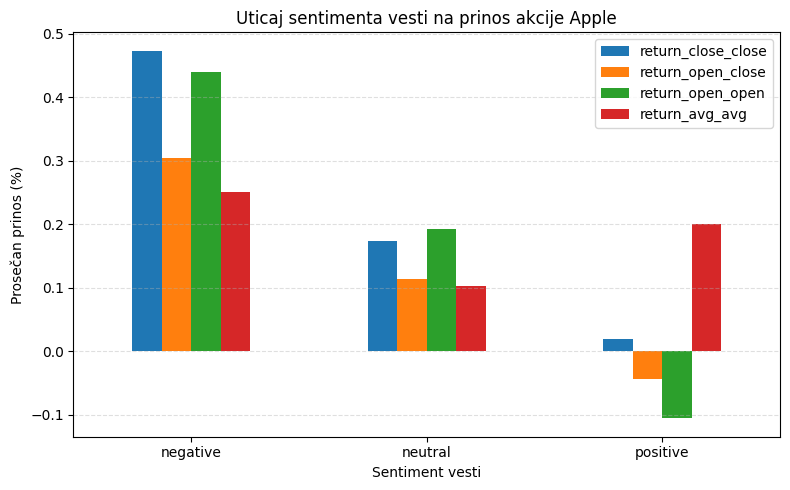

In [ ]:
import matplotlib.pyplot as plt

returns_by_sentiment = daily_sentiment.groupby(pd.cut(
    daily_sentiment["daily_sentiment_score"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
), observed=True)[[
    "return_close_close",
    "return_open_close",
    "return_open_open",
    "return_avg_avg"
]].mean()

# u procente
returns_by_sentiment_percent = returns_by_sentiment * 100

# plot
returns_by_sentiment_percent.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Uticaj sentimenta vesti na prinos akcije Apple")
plt.xlabel("Sentiment vesti")
plt.ylabel("Prosečan prinos (%)")

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

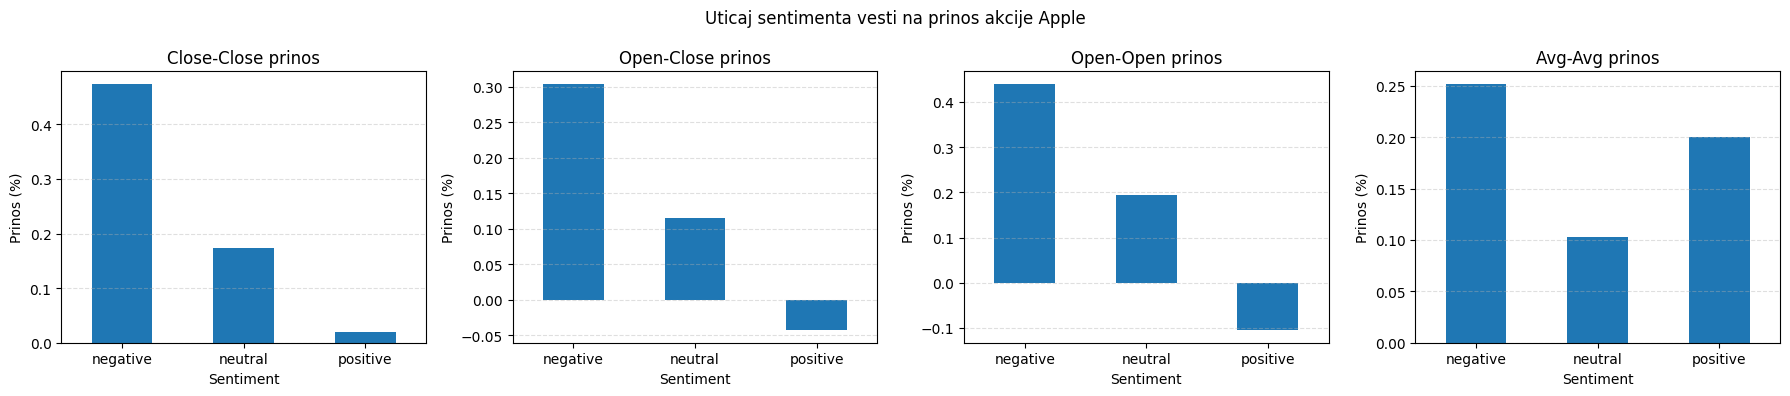

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18,4))

# Close-Close
returns_by_sentiment_percent["return_close_close"].plot(kind="bar", ax=axes[0])
axes[0].set_title("Close-Close prinos")

# Open-Close
returns_by_sentiment_percent["return_open_close"].plot(kind="bar", ax=axes[1])
axes[1].set_title("Open-Close prinos")

# Open-Open
returns_by_sentiment_percent["return_open_open"].plot(kind="bar", ax=axes[2])
axes[2].set_title("Open-Open prinos")

# Avg-Avg
returns_by_sentiment_percent["return_avg_avg"].plot(kind="bar", ax=axes[3])
axes[3].set_title("Avg-Avg prinos")

for ax in axes:
    ax.set_xlabel("Sentiment")
    ax.set_ylabel("Prinos (%)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle("Uticaj sentimenta vesti na prinos akcije Apple")

plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

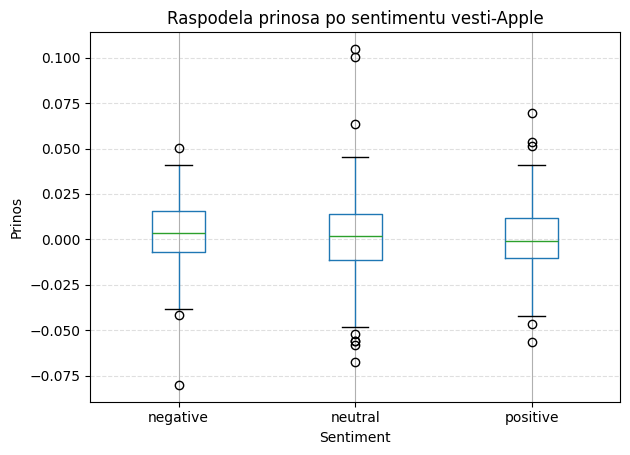

In [ ]:
import matplotlib.pyplot as plt

# kopija podataka
df_daily = daily_sentiment.copy()

# formiranje grupa na osnovu daily_sentiment_class
df_daily["sentiment_group"] = pd.cut(
    df_daily["daily_sentiment_class"],
    bins=[-1, -0.1, 0.1, 1],
    labels=["negative", "neutral", "positive"]
)

# boxplot
plt.figure(figsize=(6,4))

df_daily.boxplot(
    column="return_close_close",
    by="sentiment_group"
)

plt.title("Raspodela prinosa po sentimentu vesti-Apple")
plt.suptitle("")  # uklanja default naslov
plt.xlabel("Sentiment")
plt.ylabel("Prinos")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

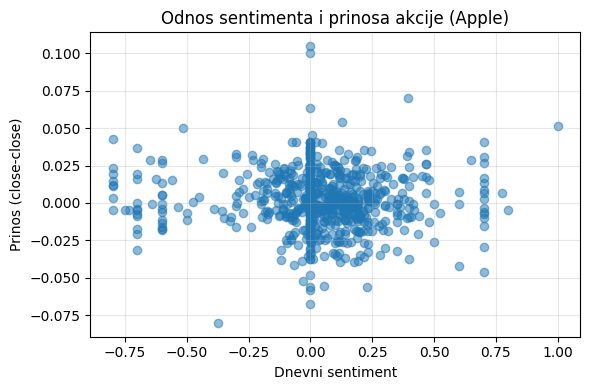

In [ ]:
import matplotlib.pyplot as plt

# uklonjeno NaN
df_daily = daily_sentiment.dropna(subset=["daily_sentiment_score", "return_close_close"])

plt.figure(figsize=(6,4))

plt.scatter(
    df_daily["daily_sentiment_score"],
    df_daily["return_close_close"],
    alpha=0.5
)

plt.title("Odnos sentimenta i prinosa akcije (Apple)")
plt.xlabel("Dnevni sentiment")
plt.ylabel("Prinos (close-close)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
aapl_tagged["date"] = pd.to_datetime(aapl_tagged["date"], errors="coerce")
aapl_prices["date"] = pd.to_datetime(aapl_prices["date"], errors="coerce")



aapl_tagged = aapl_tagged.sort_values("date")
aapl_prices = aapl_prices.sort_values("date")

In [ ]:
print(aapl_tagged["date"].dtype)
print(aapl_prices["date"].dtype)

datetime64[ns]
datetime64[ns]


In [ ]:
print(len(aapl_merged))
print(len(aapl_tagged))

aapl_merged[["date", "title"]].head()
aapl_tagged[["date", "title", "sentiment", "sentiment_score"]].head()

29725
29725


,date,title,sentiment,sentiment_score
0,2016-02-19,Payment Data Systems Announces Apple Pay Suppo...,positive,0.7
1,2017-10-05,New Research: Key Drivers of Growth for Micros...,neutral,0.0
2,2017-11-27,"Factors of Influence in 2018, Key Indicators a...",neutral,0.0
3,2017-11-30,"BioTelemetry, Inc. Enters Agreement to Provide...",positive,0.8
4,2018-01-31,Investor Expectations to Drive Momentum within...,neutral,0.0


In [ ]:
aapl_final = aapl_merged.copy()

aapl_final["sentiment"] = aapl_tagged["sentiment"].values
aapl_final["sentiment_score"] = aapl_tagged["sentiment_score"].values
aapl_final["topic"] = aapl_tagged["topic"].values
aapl_final["sentiment_num"] = aapl_tagged["sentiment_num"].values

In [ ]:
aapl_final.columns

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos',
       'year', 'close_t', 'close_t1', 'close_t2', 'close_t3', 'close_t5',
       'close_t7', 'open_t1', 'open_t2', 'high_t1', 'high_t2', 'high_t3',
       'low_t1', 'low_t2', 'low_t3', 'avg_t', 'avg_t1', 'return_close_close',
       'return_open_close', 'return_open_open', 'return_avg_avg', 'return_2d',
       'return_3d', 'return_5d', 'return_7d', 'y_1d', 'y_2d', 'y_3d', 'y_5d',
       'y_7d', 'max_high_3d', 'min_low_3d', 'up_move_3d', 'down_move_3d',
       'y_prof_3d', 'company', 'direction_close_close', 'direction_open_close',
       'direction_open_open', 'direction_avg_avg', 'sentiment',
       'sentiment_score', 'topic', 'sentiment_num'],
      dtype='object')

In [ ]:
len(aapl_final)

29725

In [ ]:
aapl_final["return_prof_3d"] = (
    abs(aapl_final["max_high_3d"] - aapl_final["close_t"]) -
    abs(aapl_final["min_low_3d"] - aapl_final["close_t"])
) / aapl_final["close_t"]

In [ ]:
aapl_final.to_csv("/content/drive/MyDrive/aapl_final2.csv", index=False)

In [ ]:
aapl_final[["sentiment_score", "return_close_close"]].corr()

,sentiment_score,return_close_close
sentiment_score,1.000000,0.005327
return_close_close,0.005327,1.000000


In [ ]:
aapl_final[["sentiment_score", "return_avg_avg"]].corr()

,sentiment_score,return_avg_avg
sentiment_score,1.000000,0.031293
return_avg_avg,0.031293,1.000000


In [ ]:
aapl_final[["sentiment_score", "return_prof_3d"]].corr()

,sentiment_score,return_prof_3d
sentiment_score,1.000000,-0.024091
return_prof_3d,-0.024091,1.000000


In [ ]:
corr = aapl_final[[
    "sentiment_score",
    "return_close_close",
    "return_avg_avg",
    "return_2d",
    "return_3d"
]].corr()

print(corr)

                    sentiment_score  return_close_close  return_avg_avg  \
sentiment_score            1.000000            0.005327        0.031293   
return_close_close         0.005327            1.000000        0.793389   
return_avg_avg             0.031293            0.793389        1.000000   
return_2d                 -0.013578            0.707485        0.547761   
return_3d                 -0.034600            0.546818        0.421114   

                    return_2d  return_3d  
sentiment_score     -0.013578  -0.034600  
return_close_close   0.707485   0.546818  
return_avg_avg       0.547761   0.421114  
return_2d            1.000000   0.788438  
return_3d            0.788438   1.000000  


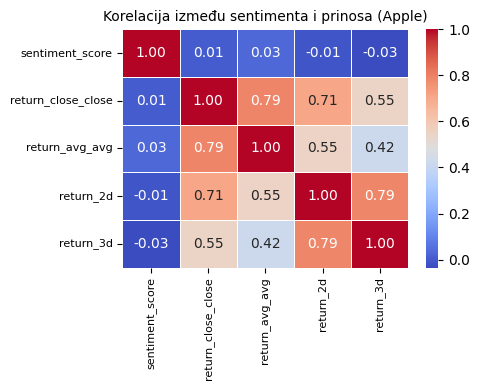

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Korelacija između sentimenta i prinosa (Apple)", fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()



plt.show()

In [ ]:
aapl_final.groupby("y_prof_3d")["sentiment_score"].mean()

,sentiment_score
y_prof_3d,
0,0.074513
1,0.058042


In [ ]:
aapl_final.to_csv("/content/drive/MyDrive/aapl_final2.csv", index=False)